# Plots for figure 2

## Different training identities

70-95% Evaluation is done on Test sequences


## Family Temperature shift 
<pre>
COG       | Families  
----------+-------------------------
COG1012@1 | Acyl-CoA reductasee      
COG1028@1 | FabG/SDR dehydrogenase       
COG0108@1 | RibB / DHBP
COG0062@1 | Nnr/NAXE 
COG0065@1 | LeuC  
COG0039@1 | MDH  
COG0673@1 | MviM-like dehydrogenase 
COG3842@1 | ABC transporter ATPase 
COG2032@1 | SODC 
COG4188@1 | α/β-hydrolase 

</pre>
## Aminoacid enrichment




## Aminoacid pairwise substitution


## Embeddings Umap



## Tree


## Origin

<pre>
/Users/sandravi/Documents/Projects/ThermalGAN/Scripts/THOR Training/Training_different_Target_identities.ipynb
vault/Sandra/ThermalGAN/src/scripts/data_processing/Data_validation/OGT_IMG_data_preparation.ipynb
vault/Sandra/ThermalGAN/src/scripts/analysis/THOR_WT_Variant_substitutions.ipynb
/Users/sandravi/Documents/Projects/ThermalGAN/Scripts/THOR Aalysis/Embedings_projection.ipynb
</pre>


In [9]:
%load_ext autoreload
%autoreload 1

import pandas as pd
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage.filters import gaussian_filter1d
import matplotlib.colors as mcolors

from Bio import SeqIO
import glob
import numpy as np
import warnings
warnings.filterwarnings('ignore')



from tqdm import tqdm
tqdm.pandas()


%aimport Helpers.helper_figure2
import Helpers.helper_figure2 as hf2

#from numba import jit

# Different training identities

In [2]:
ids=["70", "75", "80","85","90","95"]

files_val=[f"../Data/Figure2/validation_history_{ident}.csv" for ident in ids]

files_train=[f"../Data/Figure2/training_history_{ident}.csv" for ident in ids]
files_test=[f"../Data/Figure2/test_history_{ident}.csv" for ident in ids]



df_val=[]
for file, _id in zip(files_val, ids):
    df_tmp = pd.read_csv(file)
    df_tmp["Target_dentity"] = [_id for _ in range(df_tmp.shape[0])]
    df_val.append(df_tmp)
df_val = pd.concat(df_val)

df_train=[]
for file, _id in zip(files_train, ids):
    df_tmp = pd.read_csv(file)
    df_tmp["Target_dentity"] = [_id for _ in range(df_tmp.shape[0])]
    df_train.append(df_tmp)
df_train = pd.concat(df_train)

df_test=[]
for file, _id in zip(files_test, ids):
    df_tmp = pd.read_csv(file)
    df_tmp["Target_dentity"] = [_id for _ in range(df_tmp.shape[0])]
    df_test.append(df_tmp)
df_test = pd.concat(df_test)

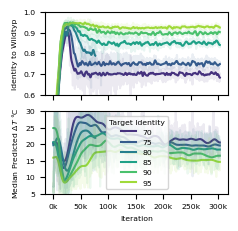

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import gaussian_filter1d
import seaborn as sns

mm = 1 / 25.4
fig_w = 60 * mm
fig_h = 60 * mm

fig, ax1 = plt.subplots(2, figsize=(fig_w, fig_h))

df = df_val

palette = sns.color_palette("viridis", n_colors=len(ids))

ax1[0].set_ylim([0.6, 1])

for color, Ident in zip(palette, ids):
    df_tmp = df.loc[df["Target_dentity"] == Ident]
    df_tmp = df_tmp.iloc[:3000]
    X = (df_tmp["Unnamed: 0"] + 1) * 101
    Y = df_tmp["acc_x"]
    Y_smoothed = gaussian_filter1d(Y, sigma=10)

    ax1[0].plot(X, Y_smoothed, c=color)

ax1[0].set_xticklabels(["", "", "", "", "", "", ""])

for color, Ident in zip(palette, ids):
    df_tmp = df.loc[df["Target_dentity"] == Ident]
    df_tmp = df_tmp.iloc[:3000]
    X = (df_tmp["Unnamed: 0"] + 1) * 101
    Y = df_tmp["acc_x"]

    ax1[0].plot(X, Y, alpha=0.1, c=color)

ax1[0].set_ylabel("Identity to Wildtyp", fontsize=5.5)

ax1[1].set_ylim([5, 30])

for color, Ident in zip(palette, ids):
    df_tmp = df.loc[df["Target_dentity"] == Ident]
    df_tmp = df_tmp.iloc[:3000]
    X = (df_tmp["Unnamed: 0"] + 1) * 101
    Y = df_tmp["temp_diff_x"]
    Y_smoothed = gaussian_filter1d(Y, sigma=50)

    ax1[1].plot(X, Y_smoothed, c=color)

for color, Ident in zip(palette, ids):
    df_tmp = df.loc[df["Target_dentity"] == Ident]
    df_tmp = df_tmp.iloc[:3000]
    X = (df_tmp["Unnamed: 0"] + 1) * 101
    Y = df_tmp["temp_diff_x"]

    ax1[1].plot(X, Y, alpha=0.1, c=color)

ax1[1].legend(
    ids,
    title="Target Identity",
    loc="center",
    #bbox_to_anchor=(-0.2, 1.2),
    ncol=1,
    fancybox=True,
    shadow=False,
    fontsize=5.5,
    title_fontsize=5.5,
)

ax1[1].set_xlabel("Iteration", fontsize=5.5)
#ax1[0].set_xlabel("Iteration", fontsize=5.5)
ax1[1].set_ylabel(r"Median Predicted $\Delta T$ $\degree$C", fontsize=5.5)
#ax1[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:g}k"))
ax1[1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1000:g}k"))

ax1[0].tick_params(axis="x", labelsize=5.5)
ax1[1].tick_params(axis="x", labelsize=5.5)
ax1[0].tick_params(axis="y", labelsize=5.5)
ax1[1].tick_params(axis="y", labelsize=5.5)

plt.savefig("../Results/Figure2/WtIdentity_dT_during_training.pdf", bbox_inches="tight")
plt.show()

# Family Temperature shift 

In [4]:

df_test_COG = pd.read_csv("../Data/Figure2/ALL_Enzyme_test.csv")

epoch=30
df = load_fasta(f"../Data/Figure2/variants_{epoch}.fasta")
df = df.loc[df["pOGT_wt"]<45]
df["Identity"] = df.progress_apply(lambda x: id2wt(x["seq_var"], x["seq_wt"]), axis = 1)
mask = np.logical_and(df["Identity"]<=0.95, df["Identity"]>=0.75)
print(f"Excluding: {len(mask) - sum(mask)} Variants")
df = df.loc[mask]
df = df.loc[df.groupby('id_wt')['pOGT_var'].idxmax()]
df = df.merge(df_test_COG, left_on="id_wt", right_on="#query")
df["seq_length"] = df.progress_apply(lambda x: len(x["seq_var"]), axis = 1)


100%|██████████| 628624/628624 [00:05<00:00, 119062.72it/s]


Excluding: 122192 Variants


100%|██████████| 260609/260609 [00:00<00:00, 480448.79it/s]


COG: COG1012@1|root       median diff: 35.214687 mean diff: 34.436312 min diff: -10.852936 max diff: 75.609758 median identity  0.829317
COG: COG1028@1|root       median diff: 21.472857 mean diff: 23.517603 min diff: -13.347437 max diff: 71.029505 median identity  0.845528
COG: COG0108@1|root       median diff: 28.030375 mean diff: 28.482977 min diff: -13.842123 max diff: 71.746290 median identity  0.786600
COG: COG0062@1|root       median diff: 19.426138 mean diff: 22.899229 min diff: -8.222803 max diff: 69.420378 median identity  0.824131
COG: COG0065@1|root       median diff: 22.747253 mean diff: 23.538616 min diff: -12.447496 max diff: 74.513115 median identity  0.864693
COG: COG0039@1|root       median diff: 35.433004 mean diff: 33.879088 min diff: -17.702137 max diff: 76.110868 median identity  0.819048
COG: COG0673@1|root       median diff: 30.168182 mean diff: 29.953351 min diff: -15.298468 max diff: 83.524609 median identity  0.826347
COG: COG3842@1|root       median diff: 29.

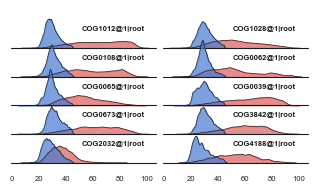

In [5]:
df = df.loc[~df['root_COG'].isin(["Null", 'MDH'])]
for OG in df["root_COG"].unique():
    df_tmp_og = df.loc[df["root_COG"]==OG]
    diff = df_tmp_og["pOGT_var"].values - df_tmp_og["pOGT_wt"].values
    median_diff = np.median(diff)
    mean_diff = np.mean(diff)
    min_diff = np.min(diff)
    max_diff = np.max(diff)
    median_id = df_tmp_og["Identity"].median()
    print(f"COG: {OG:20s} median diff: {median_diff:9f} mean diff: {mean_diff:9f} min diff: {min_diff:9f} max diff: {max_diff:9f} median identity {median_id:9f}")
    

#df = df.loc[~df['OG'].isin(["Null", 'MDH', 'CuSOD'])]
diff = df["pOGT_var"].values - df["pOGT_wt"].values
median_diff = np.median(diff)
mean_diff = np.mean(diff)
min_diff = np.min(diff)
max_diff = np.max(diff)
median_id = df["Identity"].median()
print(f"All median diff: {median_diff:9f} median identity {median_id}")

sns.set_theme(
    style="white",
    rc={
        "axes.facecolor": (0, 0, 0, 0),
        "font.size": 5.5,
        "axes.labelsize": 5.5,
        "xtick.labelsize": 5.5,
        "ytick.labelsize": 5.5,
    },
)

# muted colors: choose one cool and one warm
muted = sns.color_palette("muted")
cold_color = muted[0]   # muted blue
warm_color = muted[3]   # muted red/orange

line_w = 0.5

# Facet size chosen to land near ~55 mm total width with 2 columns
g = sns.FacetGrid(
    df,
    col="root_COG",
    hue="root_COG",
    col_wrap=2,
    height=0.42,   # inches per facet
    aspect=2.4     # width / height per facet
)

# variant distribution
g.map(
    sns.kdeplot,
    "pOGT_var",
    bw_adjust=0.5,
    clip_on=False,
    fill=True,
    alpha=0.7,
    linewidth=line_w,
    color=warm_color,
)

# wildtype distribution
g.map(
    sns.kdeplot,
    "pOGT_wt",
    bw_adjust=0.5,
    clip_on=False,
    fill=True,
    alpha=0.7,
    linewidth=line_w,
    color=cold_color,
)

# outlines
g.map(
    sns.kdeplot,
    "pOGT_var",
    clip_on=False,
    color="k",
    lw=line_w,
    bw_adjust=0.5,
)

g.map(
    sns.kdeplot,
    "pOGT_wt",
    clip_on=False,
    color="k",
    lw=line_w,
    bw_adjust=0.5,
)

g.refline(y=0, linewidth=0.8, linestyle="-", color="k", clip_on=False)

# panel labels
def label(x, color, label):
    ax = plt.gca()
    ax.text(
        0.7, 0.5, label,
        fontweight="demibold",
        color="k",
        ha="center",
        va="center",
        fontsize=5.5,
        transform=ax.transAxes
    )

g.map(label, "pOGT_var")

# overlap panels a bit
g.figure.subplots_adjust(hspace=-0.25,wspace=0.05)

# optional: force exact outer figure size
mm = 1 / 25.4
g.figure.set_size_inches(110 * mm, 55 * mm)

#g.figure.suptitle("Absolute Temperature", fontsize=6, y=1.02)

g.set_titles("")
g.set(yticks=[], ylabel="",xlabel="")
g.despine(bottom=True, left=True)

plt.savefig(
    f"../Results/Figure2/THOR_Enzyme-test_temp_shift_families_epoch{epoch}.pdf",
    bbox_inches="tight",
    transparent=True,
)
plt.show()

# Aminoacid enrichment

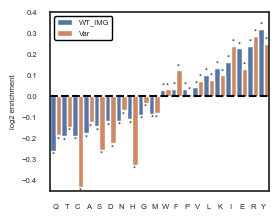

In [6]:
WT_test_uniprot = "../Data/Figure2/Enzyme_test_Uniprot.fasta"
WT_test_IMG = "../Data/Figure2/Enzyme_test_IMG.fasta"

WT_test_uniprot_df = load_fasta_aasub(WT_test_uniprot)
WT_test_IMG_df = load_fasta_aasub(WT_test_IMG)

epoch=30
name=f"../Data/Figure2/variants_epoch{epoch}_best"
variants_PF = pd.read_csv(f"{name}.csv")

aas = 'ACDEFGHIKLMNPQRSTVWY'
group_dict={"WT_Uniprot":{"count":0,"AA_count":{aa:0 for aa in aas}},
           "WT_IMG":{"count":0,"AA_count":{aa:0 for aa in aas}},
           "Var":{"count":0,"AA_count":{aa:0 for aa in aas}}}



###################### Statistics calc #############################
        
for row in WT_test_uniprot_df.iterrows():
    add_aa2dict(row[1]["seq"], group_dict["WT_Uniprot"])
    
for row in WT_test_IMG_df.iterrows():
    add_aa2dict(row[1]["seq"], group_dict["WT_IMG"])
        
for row in variants_PF.iterrows():
    add_aa2dict(row[1]["seq_var"], group_dict["Var"])

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

data = group_dict  # your dict above

ref = "WT_Uniprot"
datasets = [k for k in data.keys() if k != ref]

aa_list = list(data[ref]["AA_count"].keys())

results = []

for dataset in datasets:
    for aa in aa_list:
        ref_count = data[ref]["AA_count"][aa]
        ref_total = data[ref]["count"]

        ds_count = data[dataset]["AA_count"][aa]
        ds_total = data[dataset]["count"]

        # contingency table
        table = [
            [ds_count, ds_total - ds_count],
            [ref_count, ref_total - ref_count]
        ]

        oddsratio, p = fisher_exact(table)

        # frequencies
        freq_ds = ds_count / ds_total
        freq_ref = ref_count / ref_total

        log2fc = np.log2(freq_ds / freq_ref)

        results.append({
            "dataset": dataset,
            "AA": aa,
            "freq_ds": freq_ds,
            "freq_ref": freq_ref,
            "log2FC": log2fc,
            "pvalue": p
        })

df = pd.DataFrame(results)

# multiple testing correction
df["padj"] = multipletests(df["pvalue"], method="fdr_bh")[1]


#################################### Plotting #######################################

# order by WT_IMG enrichment
order = (
    df[df["dataset"] == "WT_IMG"]
    .sort_values("log2FC")["AA"]
    .tolist()
)
mm = 1 / 25.4
fig_w = 70 * mm
fig_h = 55 * mm
fig, ax = plt.subplots(figsize=(fig_w, fig_h),)
#plt.figure(layout='constrained', figsize=[7,4])
ax = sns.barplot(
    data=df,
    x="AA",
    y="log2FC",
    hue="dataset",
    order=order,
    width=1,
)
plt.ylim([-0.45,0.4])
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("")#("Amino Acid")
plt.ylabel("log2 enrichment", fontsize=5.5)
#plt.title("Amino Acid Enrichment Relative to WT_Uniprot\nOrdered by WT_IMG enrichment")

ax.tick_params(axis="x", labelsize=5.5)
ax.tick_params(axis="y", labelsize=5.5)

ax.legend(
    fontsize=5.5,
    title_fontsize=5.5,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1,
)

# map AA to plotted x-position
xpos = {aa: i for i, aa in enumerate(order)}

# add significance marks
for _, row in df.iterrows():
    if row["padj"] < 0.05:
        x = xpos[row["AA"]]
        offset = -0.2 if row["dataset"] == "WT_IMG" else 0.2
        y = row["log2FC"]

        # place star slightly above positive bars, slightly below negative bars
        star_y = y + 0.005 if y >= 0 else y - 0.005
        va = "bottom" if y >= 0 else "top"

        ax.text(
            x + offset,
            star_y,
            "*",
            ha="center",
            va=va,
            fontsize=5.5
        )

plt.tight_layout()
plt.savefig(f"../Results/Figure2/aminoacid_enrichment_IMG_THOR-epoch{epoch}.pdf", bbox_inches="tight")
plt.show()

# Aminoacid pairwise substitution

## Computing Alignment assosiated substitutions

method based on https://www.science.org/doi/10.1126/science.aay2784

In [19]:
files = glob.glob("../Data/Figure2/cluster_pipeline_results_30/*/alignments/*")

total_mat_wt, pair_signs_all_wt, all_tests_wt, n_used_wt = hf2.analyze_many_alignments_paper_like_wt(
    files,
    collapse_by_organism=True,   # closer to the paper
    correction="fdr_bh",     # closer to the paper
    alpha=0.01,                  # paper used Bonferroni with 0.01 family-wise cutoff
    min_group_size=5
)

100%|██████████| 60/60 [05:34<00:00,  5.58s/it]


## Plotting Wildtype assosiated substitutions

Used 60 alignments
Total temperature-associated substitution mass: 3859.000


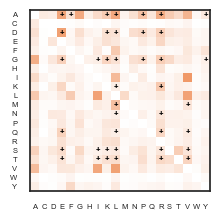

In [ ]:
sub_freq_wt = hf2.matrix_to_relative_frequency(total_mat_wt)
sig_plus_wt = hf2.compute_preferred_direction_plus(
    pair_signs_all_wt,
    correction="fdr_bh",   # reasonable for the reciprocal-direction overlay
    alpha=0.01,
    min_n=100
)
print(f"Used {n_used_wt} alignments")
print(f"Total temperature-associated substitution mass: {total_mat_wt.sum():.3f}")
hf2.plot_substitution_heatmap_wt(
    sub_freq_wt,
    sig_plus=sig_plus_wt,
    title="Temperature-associated substitutions\nrows = mesophilic/Uniprot, columns = thermophilic/IMG"
)
plt.savefig(f"../Results/Figure2/substitution_matrix_uniprot_IMG.pdf", bbox_inches="tight")
plt.show()


## Plotting THOR assosiated substitutions

Sequence pairs used: 260609
Total substitutions counted: 14951483


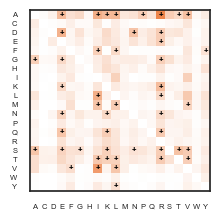

,wt_res,var_res,substitution,count,frequency
0,A,R,A->R,289398,0.019356
1,V,I,V->I,234455,0.015681
2,A,I,A->I,190024,0.012709
3,L,I,L->I,189839,0.012697
4,D,E,D->E,181725,0.012154
...,...,...,...,...,...
95,L,F,L->F,54767,0.003663
96,N,G,N->G,54694,0.003658
97,M,Y,M->Y,54672,0.003657
98,C,I,C->I,54669,0.003656


In [23]:
epoch = 30
df_thor = pd.read_csv(f"../Data/Figure2/variants_epoch{epoch}_best.csv")
sub_counts_thor, pair_signs_all_thor, n_pairs_used_thor, total_substitutions_thor = hf2.build_paired_substitution_matrix_thor(
    df_thor,
    wt_col="seq_wt",
    var_col="seq_var"
)

sub_freq_thor = hf2.counts_to_relative_frequency_thor(sub_counts_thor)

sig_pref_thor, pval_matrix_thor, qval_matrix_thor, ninfo_matrix_thor = hf2.compute_preferred_direction_matrix_thor(
    pair_signs_all_thor,
    alpha=0.01,
    min_n=109001,
    correction="fdr_bh"
)

print(f"Sequence pairs used: {n_pairs_used_thor}")
print(f"Total substitutions counted: {total_substitutions_thor}")

hf2.plot_substitution_heatmap_thor(
    sub_freq_thor,
    sig_pref=sig_pref_thor,
    title="Model substitutions: wildtype -> variant"
)
plt.savefig(f"../Results/Figure2/substitution_matrix_uniprot_THOR-epoch{epoch}.pdf", bbox_inches="tight")
plt.show()

top_subs_thor = hf2.substitution_table_thor(sub_counts_thor, sub_freq_thor)
top_subs_thor.head(100)

# Embeddings Umap

In [26]:
df_test_COG = pd.read_csv("../Data/Figure2/annotations_enzyme_test.csv")
df = pd.read_csv("../Data/Figure2/projected_embeddings_enzyme_test.csv")

df["#query"] = df.progress_apply(lambda x: x["id"].split("_")[0] if  x["id"].split("_")[-1] == "var" else  x["id"] ,axis=1)
df = df.merge(df_test_COG[["#query", "DataSet", "root_COG", "second_order_COG"]], how = "left", on="#query")
df["Kingdom"] = df.progress_apply(lambda x: x["second_order_COG"].split('|')[-1], axis=1)
df["DataSet"] = df.progress_apply(lambda x: x["DataSet"] if not x["id"].split('_')[-1]=="var" else "Variant", axis=1)
df = df.loc[df["len"]>100]

100%|██████████| 629764/629764 [00:01<00:00, 426656.33it/s]


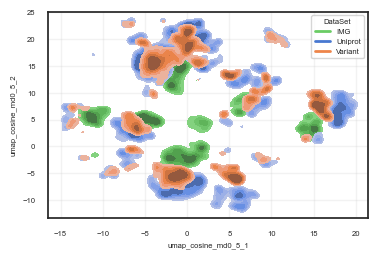

Saved contour plot to /Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure2/umap_dataset_contours_seaborn.pdf


In [29]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

if "df" not in globals():
    raise NameError("`df` is not defined. Run the cells that create `df` first.")

candidate_pairs = [
    ("umap_cosine_md0_5_1", "umap_cosine_md0_5_2"),
    ("UMAP_1", "UMAP_2"),
    ("UMAP1", "UMAP2"),
    ("x_umap", "y_umap"),
]

x_col = y_col = None
for x_name, y_name in candidate_pairs:
    if x_name in df.columns and y_name in df.columns:
        x_col, y_col = x_name, y_name
        break

if x_col is None:
    umap_cols = [c for c in df.columns if "umap" in c.lower()]
    if len(umap_cols) < 2:
        raise ValueError(f"Could not find two UMAP columns in df. Available columns: {list(df.columns)}")
    x_col, y_col = umap_cols[:2]

required_cols = [x_col, y_col, "DataSet", "Kingdom"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

df_contour = df.loc[df["Kingdom"] == "Bacteria"].copy()
df_contour = df_contour.dropna(subset=[x_col, y_col, "DataSet"])
df_contour["DataSet"] = df_contour["DataSet"].astype(str)

dataset_categories = sorted(df_contour["DataSet"].unique())
dataset_fixed_colors = {
    "Variant": "#EE854A",
    "Uniprot": "#4878D0",
    "IMG": "#6ACC64",
}
fallback_colors = sns.color_palette("tab10", n_colors=max(len(dataset_categories), 1))
dataset_color_map = {
    category: dataset_fixed_colors.get(category, fallback_colors[i % len(fallback_colors)])
    for i, category in enumerate(dataset_categories)
}

mm = 1 / 25.4
fig_w = 95 * mm
fig_h = 65 * mm
fontsize=5.5
fig, ax = plt.subplots(figsize=(fig_w, fig_h))


legend_handles = []

for category in dataset_categories:
    df_cat = df_contour.loc[df_contour["DataSet"] == category]
    if len(df_cat) < 10:
        continue

    sns.kdeplot(
        data=df_cat,
        x=x_col,
        y=y_col,
        levels=6,
        fill=True,
        thresh=0.2,
        bw_adjust=0.3,
        color=dataset_color_map[category],
        linewidths=1,
        ax=ax,
    )
    legend_handles.append(Line2D([0], [0], color=dataset_color_map[category], lw=2, label=category))

#ax.set_title("UMAP contours by DataSet (Seaborn)")
ax.set_xlabel(x_col, fontsize=fontsize)
ax.set_ylabel(y_col, fontsize=fontsize)
ax.tick_params( labelsize=fontsize)

ax.grid(True, alpha=0.25)
if legend_handles:
    ax.legend(handles=legend_handles, title="DataSet", frameon=True , fontsize=fontsize, title_fontsize=fontsize, facecolor="white",)
plt.tight_layout()
plt.show()

output_pdf = Path("../Results/Figure2/umap_dataset_contours_seaborn.pdf")
output_pdf.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_pdf, bbox_inches="tight")
print(f"Saved contour plot to {output_pdf.resolve()}")


## Tree

Tree generated in ITol 
Data for tree generation provided in Data/Figure2/TREE

Tree rooted at Archaea clade